<a href="https://colab.research.google.com/github/SahilRamdoss/Potato_Disease/blob/Colab/potato_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/SahilRamdoss/Potato_Disease.git

Cloning into 'Potato_Disease'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 31 (delta 6), reused 23 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 2.32 MiB | 28.00 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -r /content/Potato_Disease/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.3 MB/s eta 0:00:00


# Potato Disease Project

## Data Exploration

In [4]:
from glob import glob

file_paths = {
    "Healthy" : glob("/content/drive/MyDrive/Datasets/potato_data/PlantVillage/Potato___healthy/*"),
    "Early-Blight" : glob("/content/drive/MyDrive/Datasets/potato_data/PlantVillage/Potato___Early_blight/*"),
    "Late-Blight" : glob("/content/drive/MyDrive/Datasets/potato_data/PlantVillage/Potato___Late_blight/*")
}

CLASS_TO_ID = {
    "Healthy": 0,
    "Early-Blight": 1,
    "Late-Blight": 2
}

ID_TO_CLASS = {
    0: "Healthy",
    1: "Early Blight Potato",
    2: "Late Blight Potato"
}


In [3]:
FILES_PATH = file_paths["Healthy"]
# Checking if all file have the same format
for file_path in FILES_PATH:
    file_extension = (file_path.split("."))[-1]

    if file_extension.lower() != "jpg":
        print(file_extension)

In [5]:
print(f"Number of Healthy Potatoes: {len(file_paths["Healthy"])}")
print(f"Number of Potatoes with Early Blight: {len(file_paths["Early-Blight"])}")
print(f"Number of Potatoes with Late Blight: {len(file_paths["Late-Blight"])}")

Number of Healthy Potatoes: 152
Number of Potatoes with Early Blight: 1000
Number of Potatoes with Late Blight: 1000


As we can see, there is clear class imbalance. We must also try checking the diversity of the data.

Let us start by viewing some of the images.

In [10]:
print(file_paths["Healthy"][0])

/content/drive/MyDrive/Datasets/potato_data/PlantVillage/Potato___healthy/03da9931-e514-4cc7-b04a-8f474a133ce5___RS_HL 1830.JPG


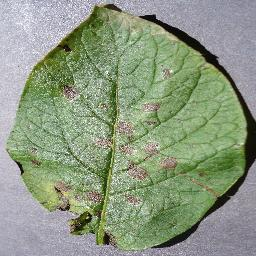

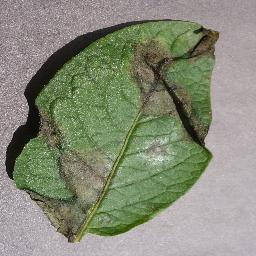

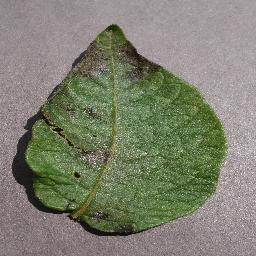

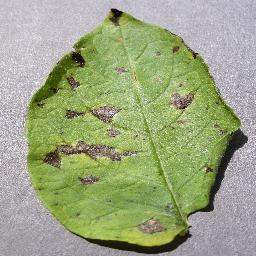

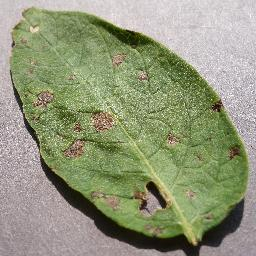

In [6]:
from IPython.display import Image
import random

# Replace with your actual file paths
IMAGE_PATHS = list()

for paths in file_paths.values():
    IMAGE_PATHS += paths

random.shuffle(IMAGE_PATHS)
NUMBER_OF_IMAGES = 5

for path in IMAGE_PATHS[:NUMBER_OF_IMAGES]:
    display(Image(filename=path, width=200))


I can see that most of the leaves are held upright. Moreover, there is clear class imbalance.

Maybe it will be good to apply some image augmentation on the training dataset...

In [7]:
import cv2
import random
from typing import List, Tuple
import numpy as np

IMG_SIZE = (256, 256)  # (width, height) for cv2.resize

def load_image(img_path: str) -> np.ndarray:
    """
    Load an image as RGB and resize to the target model input size.
    Centralizing this guarantees every image (train/val/test, every class)
    goes through identical loading/color/resizing logic.
    """
    img = cv2.imread(img_path)
    assert img is not None, f"Failed to read image: {img_path}"
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    return img

def rotation_and_scaling(img:cv2.typing.MatLike) -> cv2.typing.MatLike:
    """
    Apply random rotation and scaling to img
    """
    center = (img.shape[1] // 2, img.shape[0] // 2)
    angle = random.randint(-359,360)
    scale = random.randint(7,14) / 10.0

    # Rotation and scaling
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
    rotated_image = cv2.warpAffine(img, rotation_matrix, (img.shape[1], img.shape[0]))

    return rotated_image

def brightness_control(img: cv2.typing.MatLike)-> cv2.typing.MatLike:
    return cv2.convertScaleAbs(src=img, alpha=(random.randint(6,14) / 10), beta=1)

def augment_data(files: List[Tuple[cv2.typing.MatLike,int]], target_size: int) -> List[Tuple[cv2.typing.MatLike,int]]:

    num_loops = int(target_size // len(files)) + 1
    augmented_data = list()
    augmented_data.extend(files)
    label_id = files[0][-1]

    for _ in range(num_loops):
        for tup in files:
            if len(augmented_data) >= target_size:
                break
            img = tup[0]

            # Apply rotation and scaling
            rotated_image = rotation_and_scaling(img)

            # Brightness augmentation
            augmented_img = brightness_control(rotated_image)

            augmented_data.append((augmented_img, label_id))
        if len(augmented_data) >= target_size:
            break

    return augmented_data

In [8]:
import cv2
import matplotlib.pyplot as plt
import random

max_file_count = 0
SPLIT_RATIO = 0.8

# Get maximum number of files
for values in file_paths.values():
    if len(values) > max_file_count:
        max_file_count = len(values)

target_size = SPLIT_RATIO * max_file_count

# Obtain the train dataset for healthy potato
split_index = int(SPLIT_RATIO * len(file_paths["Healthy"]))
healthy_file_paths = (file_paths["Healthy"])
healthy_image_data = [(load_image(img_path),CLASS_TO_ID["Healthy"]) for img_path in healthy_file_paths]

train_healthy_image_data = healthy_image_data[:split_index]

augmented_healthy_image_data = augment_data(train_healthy_image_data, target_size)


In [9]:
len(augmented_healthy_image_data)

800

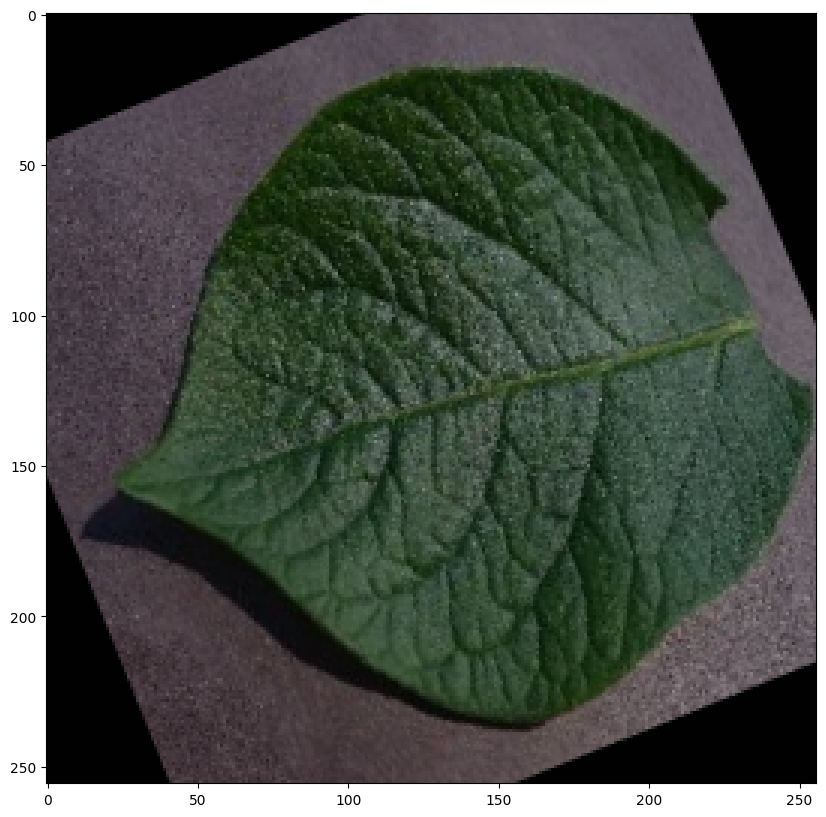

In [10]:
import random

index = random.randint(0,800)

fig, axs = plt.subplots(1,1,figsize=(10,10))
axs.imshow(augmented_healthy_image_data[index][0])

plt.show()

Now that we have performed data augmenatation, let us prepare our data into the train-test split.

In [11]:
early_blight_data = [(load_image(img), CLASS_TO_ID["Early-Blight"]) for img in file_paths["Early-Blight"]]
late_blight_data = [(load_image(img), CLASS_TO_ID["Late-Blight"]) for img in file_paths["Late-Blight"]]

In [12]:
print(late_blight_data[0][1])

2


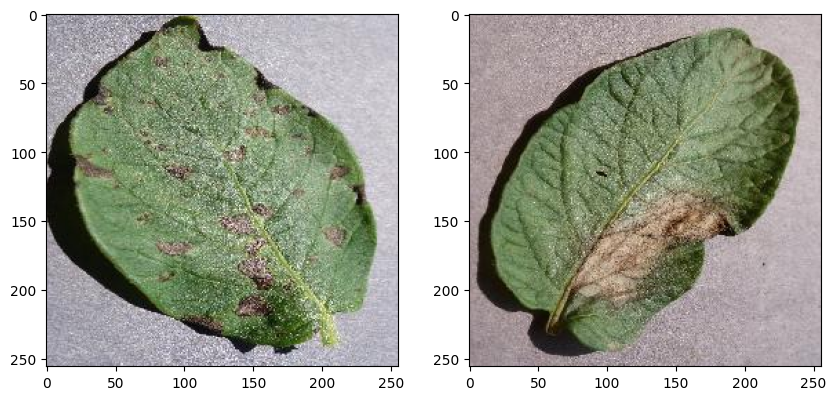

In [13]:
fig, axs = plt.subplots(1,2,figsize=(10,10))
axs[0].imshow(early_blight_data[0][0])
axs[1].imshow(late_blight_data[0][0])

plt.show()

Now we use the TF Data pipeline to prepare our datasets.

In [14]:
VAL_TEST_RATIO = 1
VAL_DATA_RATIO = round(((VAL_TEST_RATIO / (VAL_TEST_RATIO + 1)) * (1-SPLIT_RATIO)),1)
TRAIN_VAL_DATA_RATIO = VAL_DATA_RATIO + SPLIT_RATIO

target_size = int(target_size)

print("VAL_DATA_RATIO: ", VAL_DATA_RATIO)
print("TRAIN_VAL_DATA_RATIO: ", TRAIN_VAL_DATA_RATIO)

test_healthy_image_data_lower_index = int(TRAIN_VAL_DATA_RATIO * len(healthy_image_data))
test_early_blight_data_lower_index = int(TRAIN_VAL_DATA_RATIO * len(early_blight_data))
test_late_blight_data_lower_index = int(TRAIN_VAL_DATA_RATIO * len(late_blight_data))

print("test_healthy_image_data_lower_index: ", test_healthy_image_data_lower_index)
print("test_early_blight_data_lower_index: ", test_early_blight_data_lower_index)
print("test_late_blight_data_lower_index: ", test_late_blight_data_lower_index)

train_data = (augmented_healthy_image_data +
            early_blight_data[:target_size] +
            late_blight_data[:target_size])

val_data = (healthy_image_data[split_index: int(TRAIN_VAL_DATA_RATIO * len(healthy_image_data))] +
            early_blight_data[target_size: int(TRAIN_VAL_DATA_RATIO * len(early_blight_data))] +
            late_blight_data[target_size: int(TRAIN_VAL_DATA_RATIO * len(late_blight_data))])

test_data = (healthy_image_data[test_healthy_image_data_lower_index:] +
            early_blight_data[test_early_blight_data_lower_index:] +
            late_blight_data[test_late_blight_data_lower_index:])

print("train data: ", len(train_data))
print("val data: ", len(val_data))
print("test_data: ", len(test_data))


VAL_DATA_RATIO:  0.1
TRAIN_VAL_DATA_RATIO:  0.9
test_healthy_image_data_lower_index:  136
test_early_blight_data_lower_index:  900
test_late_blight_data_lower_index:  900
train data:  2400
val data:  215
test_data:  216


In [15]:
# Sanity check: confirm every image really is (256, 256, 3) before building tensors
all_shapes = {img.shape for img, _ in (train_data + val_data + test_data)}
print("Unique image shapes found:", all_shapes)
assert all_shapes == {(256, 256, 3)}, "Found inconsistent image shapes — investigate before building the dataset."

Unique image shapes found: {(256, 256, 3)}


In [16]:
train_data_images = [img for img, _ in train_data]
train_data_labels = [label for _, label in train_data]

val_data_images = [img for img, _ in val_data]
val_data_labels = [label for _, label in val_data]

test_data_images = [img for img, _ in test_data]
test_data_labels = [label for _, label in test_data]

In [24]:
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((train_data_images, train_data_labels)).shuffle(buffer_size = len(train_data), seed= 42)
val_ds = tf.data.Dataset.from_tensor_slices((val_data_images, val_data_labels)).shuffle(buffer_size = len(val_data), seed = 42)
test_ds = tf.data.Dataset.from_tensor_slices((test_data_images, test_data_labels))

In [25]:
train_ds = train_ds.batch(batch_size=32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size=32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size=32).prefetch(tf.data.AUTOTUNE)

## Building Model Architecture

In [19]:
from tensorflow.keras.layers import Input, Dense, Conv2D, BatchNormalization, Dropout, MaxPooling2D, GlobalAveragePooling2D, Normalization, Activation
from tensorflow.keras.models import Sequential

INPUT_SHAPE = (256, 256, 3)

norm_layer = Normalization(axis=None)
norm_layer.adapt(data=train_ds.map(lambda img, _ : img))

model = Sequential([
    # Input Layer
    Input(shape=INPUT_SHAPE),

    # Normalization Layer
    norm_layer,

    # Convolutional Layers
    Conv2D(filters=32, kernel_size= (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(filters=32, kernel_size= (3,3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2,2)),

    Conv2D(filters=64, kernel_size= (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(filters=64, kernel_size= (3,3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D((2,2)),

    Conv2D(filters=128, kernel_size= (3,3), padding= 'same'),
    BatchNormalization(),
    Activation('relu'),

    GlobalAveragePooling2D(),

    Dense(3, activation='softmax')
])


In [20]:
from tensorflow import keras

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[
                  keras.metrics.SparseCategoricalAccuracy()
              ])

In [21]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=16,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/16
75/75 ━━━━━━━━━━━━━━━━━━━━ 37s 203ms/step - loss: 0.4123 - sparse_categorical_accuracy: 0.8533 - val_loss: 1.0195 - val_sparse_categorical_accuracy: 0.4791
Epoch 2/16
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - loss: 0.2003 - sparse_categorical_accuracy: 0.9429 - val_loss: 1.2958 - val_sparse_categorical_accuracy: 0.4651
Epoch 3/16
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - loss: 0.1513 - sparse_categorical_accuracy: 0.9621 - val_loss: 0.9349 - val_sparse_categorical_accuracy: 0.5488
Epoch 4/16
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - loss: 0.1309 - sparse_categorical_accuracy: 0.9671 - val_loss: 0.4720 - val_sparse_categorical_accuracy: 0.7442
Epoch 5/16
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - loss: 0.1185 - sparse_categorical_accuracy: 0.9696 - val_loss: 0.2148 - val_sparse_categorical_accuracy: 0.9070
Epoch 6/16
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - loss: 0.1157 - sparse_categorical_accuracy: 0.9650 - val_loss: 0.1836 - val_sparse_categorical_accuracy: 0.916

In [22]:
model.save("/content/drive/MyDrive/models/potato_disease_classifier.keras")

## Evaluating Model

In [26]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=[ID_TO_CLASS[0], ID_TO_CLASS[1], ID_TO_CLASS[2]]
)
print(report)

                     precision    recall  f1-score   support

            Healthy       1.00      0.94      0.97        16
Early Blight Potato       0.99      0.99      0.99       100
 Late Blight Potato       0.98      0.99      0.99       100

           accuracy                           0.99       216
          macro avg       0.99      0.97      0.98       216
       weighted avg       0.99      0.99      0.99       216

